# Impor beberapa library python dan dataset dari UCI ML Repository

In [13]:
# ====================================================================
# CELL 1: MASTER IMPORTS (Semua Library Dikumpulkan di Sini)
# ====================================================================
# Library Standar & Pengolahan Data
import pandas as pd
import numpy as np
import joblib

# Library Visualisasi (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Library Computer Vision & Citra
import cv2
from PIL import Image

# Library Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Library Deep Learning (TensorFlow & Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
letter_recognition = fetch_ucirepo(id=59) 
  
# data (as pandas dataframes) 
X = letter_recognition.data.features 
y = letter_recognition.data.targets 
  
# metadata 
print(letter_recognition.metadata) 
  
# variable information 
print(letter_recognition.variables) 

y.head()

{'uci_id': 59, 'name': 'Letter Recognition', 'repository_url': 'https://archive.ics.uci.edu/dataset/59/letter+recognition', 'data_url': 'https://archive.ics.uci.edu/static/public/59/data.csv', 'abstract': 'Database of character image features; try to identify the letter', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 20000, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['lettr'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1991, 'last_updated': 'Thu Sep 28 2023', 'dataset_doi': '10.24432/C5ZP40', 'creators': ['David Slate'], 'intro_paper': None, 'additional_info': {'summary': 'The objective is to identify each of a large number of black-and-white rectangular pixel displays as one of the 26 capital letters in the English alphabet.  The character images were based on 20 different fonts and each letter within these 20 fonts wa

,lettr
0,T
1,I
2,D
3,N
4,G


# EDA with Visualization

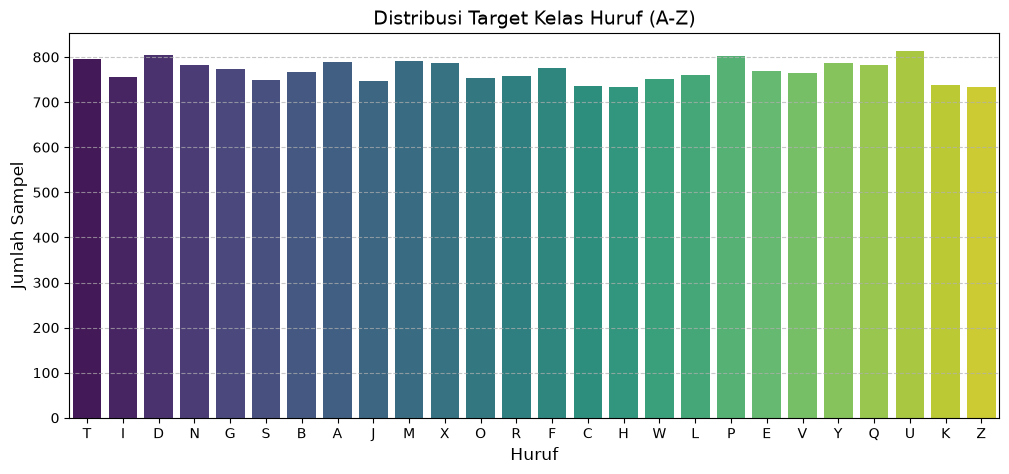

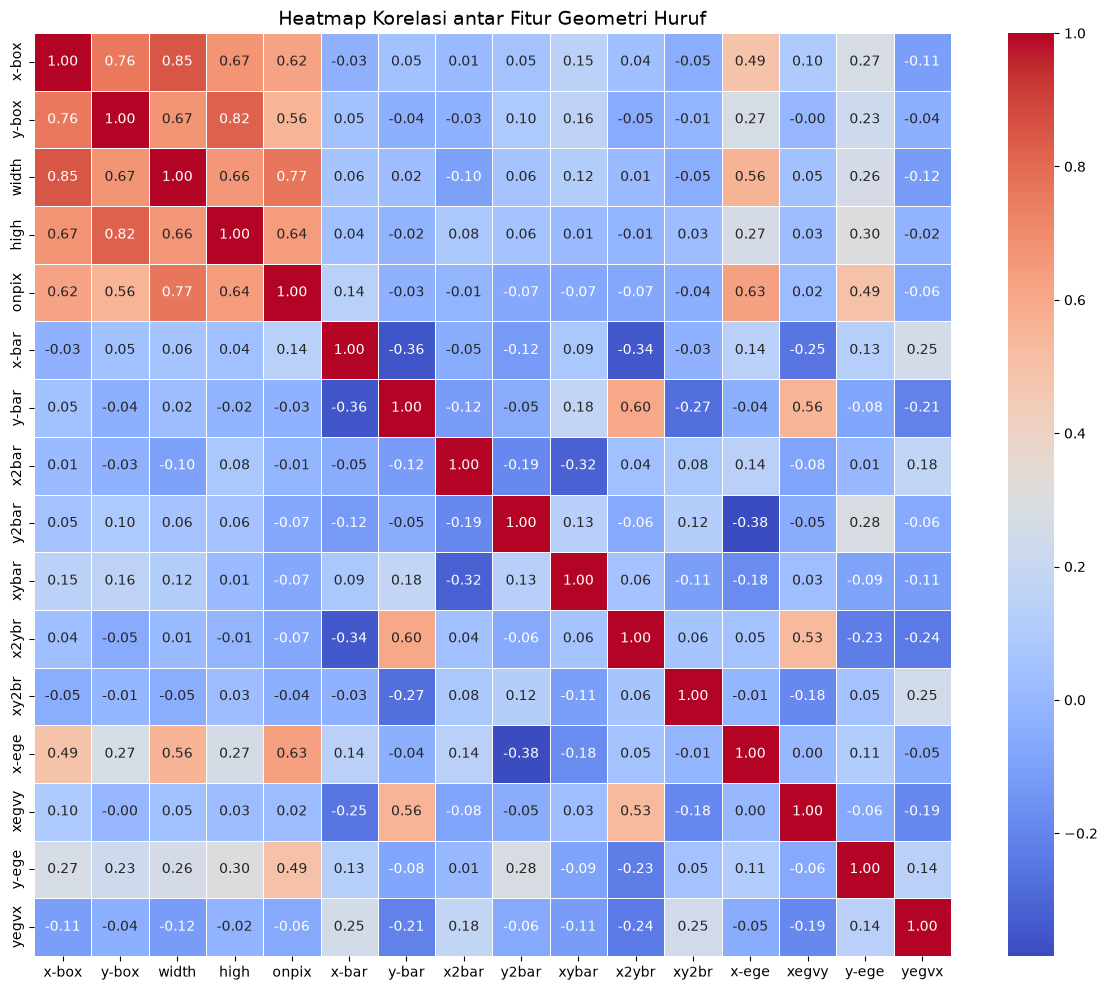

In [2]:
# --- 1. Visualisasi Distribusi Target (Bebas dari Warning) ---
plt.figure(figsize=(12, 5))
# Menggunakan parameter hue dan legend=False untuk mematuhi aturan Seaborn terbaru
sns.countplot(x=y['lettr'].sort_values(), hue=y['lettr'], palette='viridis', legend=False) 
plt.title('Distribusi Target Kelas Huruf (A-Z)', fontsize=14)
plt.xlabel('Huruf', fontsize=12)
plt.ylabel('Jumlah Sampel', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 2. Korelasi Antar Fitur Geometri (Tambahan Nilai Plus) ---
plt.figure(figsize=(12, 10))
# Menghitung korelasi dari 16 fitur numerik di variabel X
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title('Heatmap Korelasi antar Fitur Geometri Huruf', fontsize=14)
plt.tight_layout()
plt.show()

# DATA PREPROCESSING

In [3]:
# 1. Mengubah target huruf (A-Z) menjadi angka (0-25)
le = LabelEncoder()
# Mengasumsikan 'y' adalah DataFrame dengan kolom target bernama 'lettr'
y_encoded = le.fit_transform(y['lettr']) 

# 2. Membagi data menjadi Data Latih (80%) dan Data Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 3. Melakukan standarisasi/scaling pada fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Simpan Scaler dan Encoder ke file agar bisa digunakan saat Deployment nanti
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

# MODEL 1: MULTILAYER PERCEPTRON 

In [4]:
# 1. Membangun Arsitektur Neural Network
model = Sequential([
    # Input layer & Hidden layer 1 (16 input fitur)
    Input(shape=(16,)),
    Dense(128, activation='relu'),
    Dropout(0.2), # Mencegah overfitting
    
    # Hidden layer 2
    Dense(64, activation='relu'),
    
    # Output layer (26 kelas huruf dengan aktivasi softmax untuk probabilitas multiclass)
    Dense(26, activation='softmax')
])

# 2. Kompilasi Model
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# 3. Melatih Model
print("Memulai pelatihan model...")
history = model.fit(X_train_scaled, y_train, 
                    epochs=30, 
                    batch_size=32, 
                    validation_split=0.2)

# 4. Evaluasi Model pada Data Uji
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"\nAkurasi pada data uji: {accuracy * 100:.2f}%")

# 5. Simpan model yang sudah dilatih
model.save('letter_model.keras')
print("Model berhasil disimpan sebagai 'letter_model.keras'")

Memulai pelatihan model...
Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5184 - loss: 1.7274 - val_accuracy: 0.7294 - val_loss: 0.9718
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7345 - loss: 0.8896 - val_accuracy: 0.7884 - val_loss: 0.7251
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7791 - loss: 0.7170 - val_accuracy: 0.8216 - val_loss: 0.5972
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8061 - loss: 0.6288 - val_accuracy: 0.8459 - val_loss: 0.5192
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8238 - loss: 0.5589 - val_accuracy: 0.8597 - val_loss: 0.4675
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8461 - loss: 0.4997 - val_accuracy: 0.8706 - val_loss: 0.4238
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8550 - loss: 0.4649 - val_accuracy: 0.8878 - val_loss: 0.3888
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8647 - loss

# MODEL 2: RANDOM FOREST CLASSIFIER

In [5]:
# 1. Inisialisasi Model Random Forest
# n_estimators=100 berarti kita membuat 100 pohon keputusan
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Melatih Model
print("Memulai pelatihan model Random Forest...")
rf_model.fit(X_train_scaled, y_train)

# 3. Prediksi pada Data Uji
y_pred_rf = rf_model.predict(X_test_scaled)

# 4. Evaluasi Akurasi
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"\nAkurasi Random Forest pada data uji: {rf_accuracy * 100:.2f}%")

# 5. Simpan Model Random Forest
joblib.dump(rf_model, 'letter_model_rf.pkl')
print("Model Random Forest berhasil disimpan sebagai 'letter_model_rf.pkl'")

Memulai pelatihan model Random Forest...

Akurasi Random Forest pada data uji: 96.08%
Model Random Forest berhasil disimpan sebagai 'letter_model_rf.pkl'


# MODEL 3: Support Vector Machine

In [6]:
# 1. Inisialisasi Model SVM dengan Kernel RBF (Standar untuk data non-linear)
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)

# 2. Melatih Model
print("Memulai pelatihan model SVM...")
svm_model.fit(X_train_scaled, y_train)

# 3. Prediksi pada Data Uji
y_pred_svm = svm_model.predict(X_test_scaled)

# 4. Evaluasi Akurasi
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"\nAkurasi SVM pada data uji: {svm_accuracy * 100:.2f}%")

# 5. Simpan Model SVM
joblib.dump(svm_model, 'letter_model_svm.pkl')
print("Model SVM berhasil disimpan sebagai 'letter_model_svm.pkl'")

Memulai pelatihan model SVM...

Akurasi SVM pada data uji: 95.00%
Model SVM berhasil disimpan sebagai 'letter_model_svm.pkl'


# EVALUASI 3 MODEL

In [7]:
# ====================================================================
# 1. EVALUASI MODEL CLASSIC (RANDOM FOREST & SVM)
# ====================================================================
models_classic = {
    "RANDOM FOREST": y_pred_rf,  # Sesuaikan dengan nama variabel prediksi RF kamu
    "SUPPORT VECTOR MACHINE (SVM)": y_pred_svm  # Sesuaikan dengan nama variabel prediksi SVM kamu
}

for name, y_pred in models_classic.items():
    print(f"\n=================== EVALUASI {name} ===================")
    print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print("=" * 60)

# ====================================================================
# 2. EVALUASI MODEL DEEP LEARNING (MULTILAYER PERCEPTRON)
# ====================================================================
print("\n=================== EVALUASI MULTILAYER PERCEPTRON (MLP) ===================")
y_pred_mlp = model.predict(X_test_scaled)
# Konversi hasil prediksi probabilitas MLP menjadi indeks kelas (0-25)
y_pred_mlp_classes = np.argmax(y_pred_mlp, axis=1)

print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred_mlp_classes) * 100:.2f}%\n")
print(classification_report(y_test, y_pred_mlp_classes, target_names=le.classes_))
print("=" * 60)


=================== EVALUASI RANDOM FOREST ===================
Akurasi Keseluruhan: 96.08%

              precision    recall  f1-score   support

           A       0.98      1.00      0.99       149
           B       0.88      0.97      0.93       153
           C       0.99      0.92      0.95       137
           D       0.90      0.97      0.94       156
           E       0.90      0.99      0.94       141
           F       0.92      0.96      0.94       140
           G       0.98      0.96      0.97       160
           H       0.95      0.88      0.92       144
           I       0.99      0.92      0.96       146
           J       0.95      0.97      0.96       149
           K       0.94      0.89      0.92       130
           L       0.99      0.97      0.98       155
           M       0.97      0.99      0.98       168
           N       0.98      0.92      0.95       151
           O       0.95      0.95      0.95       145
           P       0.97      0.95      0.9